# Diagnostic Preservation Study — SRGAN Evaluation

Evaluates whether SRGAN super-resolved retinal fundus images preserve diagnostic
information for Diabetic Retinopathy grading.

**Pipeline:** Original HR → Degrade → SRGAN → Classifier (ResNet50 & VGG16)

**Models evaluated:** 27 SR models (srgan2 × 9, srgan31 × 9, srgan32 × 9) +
srgan-full × 9 (when available).

**Metrics:** QWK, Accuracy, Precision/Recall/F1, Sensitivity, Specificity


---
## 1. Environment Setup


In [1]:
import os, json, gc, math, random, warnings, time, sys
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Literal
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    cohen_kappa_score
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

DATA_DIR = Path(r"E:\Proyects Python based\ProyectoAvanzado2\data\processed\M3_diagnosis")
IMG_DIR = DATA_DIR / "images"
BASE_DIR = Path(r"E:\Proyects Python based\ProyectoAvanzado2\notebooks\evaluation")
BASE_DIR.mkdir(parents=True, exist_ok=True)

SR_MODELS_DIR = Path(r"E:\Proyects Python based\ProyectoAvanzado2\notebooks\models\Super-resolution")
CLASSIFIER_DIR = Path(r"E:\Proyects Python based\ProyectoAvanzado2\notebooks\models\classification")
SRGAN_FULL_DIR = Path(r"E:\Proyects Python based\ProyectoAvanzado2\models\Super-resolution\srgan-full\checkpoints")

IMG_SIZE = 224  # classifier input size
print("Setup complete.")

Device: cuda
  GPU: NVIDIA GeForce GTX 1650 with Max-Q Design
  VRAM: 4.00 GB
Setup complete.


---
## 2. Experimental Configurations (9-model matrix)


In [2]:
@dataclass
class ExperimentConfig:
    model_id: int
    scenario: Literal["A", "B", "C"]
    downsample_method: Literal["bicubic", "bilinear", "lanczos"]
    blur_sigma: float
    noise_type: Literal["gaussian", "poisson"]
    noise_param: float
    scale_factor: int

    @property
    def name(self) -> str:
        return f"model_{self.model_id}"

    @property
    def display_name(self) -> str:
        return f"M{self.model_id} (Sc.{self.scenario}, x{self.scale_factor})"

EXPERIMENTS = [
    ExperimentConfig(1, "A", "bicubic",  1.0, "gaussian",  5, 2),
    ExperimentConfig(2, "A", "bicubic",  1.0, "gaussian",  5, 4),
    ExperimentConfig(3, "A", "bicubic",  1.0, "gaussian",  5, 8),
    ExperimentConfig(4, "B", "bilinear", 1.5, "gaussian", 10, 2),
    ExperimentConfig(5, "B", "bilinear", 1.5, "gaussian", 10, 4),
    ExperimentConfig(6, "B", "bilinear", 1.5, "gaussian", 10, 8),
    ExperimentConfig(7, "C", "lanczos",  2.0, "poisson",   0, 2),
    ExperimentConfig(8, "C", "lanczos",  2.0, "poisson",   0, 4),
    ExperimentConfig(9, "C", "lanczos",  2.0, "poisson",   0, 8),
]

print("9 experiment configs:")
for cfg in EXPERIMENTS:
    print(f"  {cfg.display_name}: {cfg.downsample_method}, blur={cfg.blur_sigma}, {cfg.noise_type}, x{cfg.scale_factor}")

9 experiment configs:
  M1 (Sc.A, x2): bicubic, blur=1.0, gaussian, x2
  M2 (Sc.A, x4): bicubic, blur=1.0, gaussian, x4
  M3 (Sc.A, x8): bicubic, blur=1.0, gaussian, x8
  M4 (Sc.B, x2): bilinear, blur=1.5, gaussian, x2
  M5 (Sc.B, x4): bilinear, blur=1.5, gaussian, x4
  M6 (Sc.B, x8): bilinear, blur=1.5, gaussian, x8
  M7 (Sc.C, x2): lanczos, blur=2.0, poisson, x2
  M8 (Sc.C, x4): lanczos, blur=2.0, poisson, x4
  M9 (Sc.C, x8): lanczos, blur=2.0, poisson, x8


---
## 3. SRGAN Generator Architectures

Two architectures:
- **srgan2/srgan31/srgan32:** 3-layer Conv + PixelShuffle (baseline SR-G)
- **srgan-full:** 4 ResBlock + WeightNorm + PixelShuffle + Tanh


In [3]:
# Architecture A: 3-layer SR-G (used by srgan2, srgan31, srgan32)
class SRGenerator3Layer(nn.Module):
    def __init__(self, scale: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 3 * (scale ** 2), 3, padding=1),
            nn.PixelShuffle(scale),
        )

    def forward(self, x):
        return self.net(x)


# Architecture B: SRGAN-full (4 ResBlock + WeightNorm + Tanh)
class ResBlock(nn.Module):
    def __init__(self, channels: int = 64):
        super().__init__()
        self.block = nn.Sequential(
            nn.utils.weight_norm(nn.Conv2d(channels, channels, 3, 1, 1)),
            nn.PReLU(),
            nn.utils.weight_norm(nn.Conv2d(channels, channels, 3, 1, 1)),
        )

    def forward(self, x):
        return x + self.block(x)


class SRGeneratorFull(nn.Module):
    def __init__(self, scale_factor: int, n_res_blocks: int = 4, channels: int = 64):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(3, channels, 9, 1, 4),
            nn.PReLU(),
        )
        self.res_blocks = nn.Sequential(*[ResBlock(channels) for _ in range(n_res_blocks)])
        self.post_res = nn.Sequential(
            nn.utils.weight_norm(nn.Conv2d(channels, channels, 3, 1, 1)),
        )
        n_ups = int(math.log2(scale_factor))
        ups_layers = []
        for _ in range(n_ups):
            ups_layers += [
                nn.utils.weight_norm(nn.Conv2d(channels, channels * 4, 3, 1, 1)),
                nn.PixelShuffle(2),
                nn.PReLU(),
            ]
        self.upsample = nn.Sequential(*ups_layers)
        self.tail = nn.Conv2d(channels, 3, 9, 1, 4)
        self.tanh = nn.Tanh()

    def forward(self, x):
        head_out = self.head(x)
        res_out = self.post_res(self.res_blocks(head_out))
        up = self.upsample(head_out + res_out)
        return self.tanh(self.tail(up))


# Verify both architectures
for scale in [2, 4, 8]:
    g = SRGenerator3Layer(scale)
    n = sum(p.numel() for p in g.parameters())
    test_in = torch.randn(1, 3, 64, 64)
    test_out = g(test_in)
    print(f"SR-G 3Layer x{scale}: {n:,} params | {test_in.shape} -> {test_out.shape}")

for scale in [2, 4, 8]:
    g = SRGeneratorFull(scale)
    n = sum(p.numel() for p in g.parameters())
    test_in = torch.randn(1, 3, 64, 64)
    test_out = g(test_in)
    print(f"SR-G Full   x{scale}: {n:,} params | {test_in.shape} -> {test_out.shape}")

SR-G 3Layer x2: 45,644 params | torch.Size([1, 3, 64, 64]) -> torch.Size([1, 3, 128, 128])
SR-G 3Layer x4: 66,416 params | torch.Size([1, 3, 64, 64]) -> torch.Size([1, 3, 256, 256])
SR-G 3Layer x8: 149,504 params | torch.Size([1, 3, 64, 64]) -> torch.Size([1, 3, 512, 512])
SR-G Full   x2: 512,073 params | torch.Size([1, 3, 64, 64]) -> torch.Size([1, 3, 128, 128])
SR-G Full   x4: 660,042 params | torch.Size([1, 3, 64, 64]) -> torch.Size([1, 3, 256, 256])
SR-G Full   x8: 808,011 params | torch.Size([1, 3, 64, 64]) -> torch.Size([1, 3, 512, 512])


---
## 4. Load All SRGAN Model Checkpoints

Scans available model directories and loads each generator.


In [4]:
SRGAN_FOLDERS = {
    "srgan2":   SR_MODELS_DIR / "srgan2",
    "srgan31":  SR_MODELS_DIR / "srgan31",
    "srgan32":  SR_MODELS_DIR / "srgan32",
}

srgan_models = {}  # {(folder_name, model_id): generator}
n_loaded = 0

for folder_name, folder_path in SRGAN_FOLDERS.items():
    if not folder_path.exists():
        print(f"  SKIP (not found): {folder_name}")
        continue
    for cfg in EXPERIMENTS:
        pth_path = folder_path / f"{cfg.name}.pth"
        if not pth_path.exists():
            print(f"  MISSING: {folder_name}/{cfg.name}.pth")
            continue
        gen = SRGenerator3Layer(cfg.scale_factor).to(DEVICE)
        try:
            state = torch.load(pth_path, map_location=DEVICE, weights_only=True)
            gen.load_state_dict(state)
            srgan_models[(folder_name, cfg.model_id)] = gen
            n_loaded += 1
        except Exception as e:
            print(f"  ERROR loading {folder_name}/{cfg.name}: {e}")

print(f"\nLoaded {n_loaded} SRGAN checkpoints across {len(SRGAN_FOLDERS)} folders")

# Also load srgan-full if available
srgan_full_models = {}
if SRGAN_FULL_DIR.exists():
    for cfg in EXPERIMENTS:
        best_path = SRGAN_FULL_DIR / f"{cfg.name}_best.pt"
        last_path = SRGAN_FULL_DIR / f"{cfg.name}.pt"
        ckpt_path = best_path if best_path.exists() else last_path
        if not ckpt_path.exists():
            continue
        gen = SRGeneratorFull(cfg.scale_factor).to(DEVICE)
        try:
            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
            if isinstance(ckpt, dict) and "generator_state" in ckpt:
                gen_state = ckpt["generator_state"]
            else:
                gen_state = ckpt
            gen.load_state_dict(gen_state)
            srgan_full_models[cfg.model_id] = gen
            ep = ckpt.get("epoch", "?") if isinstance(ckpt, dict) else "?"
            print(f"  Loaded srgan-full/{cfg.name} (epoch {ep})")
            if cfg.scale_factor == 2:
                print(f"    Note: x2 model collapsed (PSNR ~3.6 dB, LPIPS=NaN)")
        except Exception as e:
            print(f"  srgan-full/{cfg.name}: {e}")

if srgan_full_models:
    print(f"\nLoaded {len(srgan_full_models)} srgan-full models")
else:
    print("\nsrgan-full checkpoints not yet available (training may still be running)")


Loaded 27 SRGAN checkpoints across 3 folders
  Loaded srgan-full/model_1 (epoch 1)
    Note: x2 model collapsed (PSNR ~3.6 dB, LPIPS=NaN)
  Loaded srgan-full/model_2 (epoch 1)
  Loaded srgan-full/model_3 (epoch 1)
  Loaded srgan-full/model_4 (epoch 1)
    Note: x2 model collapsed (PSNR ~3.6 dB, LPIPS=NaN)
  Loaded srgan-full/model_5 (epoch 1)
  Loaded srgan-full/model_6 (epoch 1)
  Loaded srgan-full/model_7 (epoch 1)
    Note: x2 model collapsed (PSNR ~3.6 dB, LPIPS=NaN)
  Loaded srgan-full/model_8 (epoch 1)
  Loaded srgan-full/model_9 (epoch 1)

Loaded 9 srgan-full models


---
## 5. GPU Degradation Pipeline (Blur --> Downsample --> Noise)


In [5]:
class DegradeBatch(nn.Module):
    def __init__(self, cfg: ExperimentConfig):
        super().__init__()
        self.cfg = cfg
        ksize = int(6 * cfg.blur_sigma + 1)
        if ksize % 2 == 0:
            ksize += 1
        self.blur = transforms.GaussianBlur(ksize, cfg.blur_sigma) if ksize > 1 else nn.Identity()

    def forward(self, hr: torch.Tensor) -> tuple:
        blurred = self.blur(hr)
        lr_size = hr.shape[-1] // self.cfg.scale_factor
        interp = {"bicubic": "bicubic", "bilinear": "bilinear", "lanczos": "bicubic"}
        lr = F.interpolate(blurred, size=(lr_size, lr_size),
                          mode=interp[self.cfg.downsample_method], align_corners=False)
        lr_01 = (lr + 1) / 2
        if self.cfg.noise_type == "gaussian":
            noise = torch.randn_like(lr_01) * (self.cfg.noise_param / 255.0)
            lr_01 = lr_01 + noise
        elif self.cfg.noise_type == "poisson":
            scale = 100.0
            lr_01 = torch.poisson(lr_01.clamp(0, 1) * scale) / scale
        lr = lr_01 * 2 - 1
        return lr.clamp(-1, 1), hr

print("DegradeBatch defined.")

DegradeBatch defined.


---
## 6. Image Preprocessing Pipelines

Two different pipelines matching each classifier's training:
- **ResNet50:** crop_from_gray (no-op) --> contrast enhancement --> resize 224
- **VGG16:** PIL --> resize 224 (handled in dataset)


In [6]:
def crop_image_from_gray(img, tol=7):
    return img  # disabled (original implementation was buggy)

def contrast_enhancement(img):
    blur_size = IMG_SIZE // 30
    if blur_size % 2 == 0:
        blur_size += 1
    blurred = cv2.GaussianBlur(img, (0, 0), sigmaX=IMG_SIZE / 30)
    enhanced = cv2.addWeighted(img, 4, blurred, -4, 128)
    return enhanced

def preprocess_for_resnet(img_np: np.ndarray) -> torch.Tensor:
    # img_np: RGB uint8 [H, W, 3] at original resolution
    img = crop_image_from_gray(img_np, tol=7)
    img = contrast_enhancement(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    # Convert to tensor in [-1, 1]
    tensor = torch.from_numpy(img).permute(2, 0, 1).float() / 127.5 - 1.0
    return tensor  # [3, 224, 224] in [-1, 1]

def preprocess_for_vgg16(img_np: np.ndarray) -> torch.Tensor:
    # img_np: RGB uint8 [H, W, 3] at original resolution
    pil_img = Image.fromarray(img_np).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    tensor = transforms.ToTensor()(pil_img)  # [0, 1]
    return tensor * 2 - 1  # convert to [-1, 1]

print("Preprocessing functions defined.")

Preprocessing functions defined.


---
## 7. Load Pretrained Classifiers


In [7]:
# Optimized thresholds from ResNet50 validation
OPT_THRESHOLDS = [0.5324, 1.5332, 2.3265, 3.5474]

# ResNet50 Ordinal
print("Loading ResNet50...")
resnet50_model = models.resnet50(weights=None)
resnet50_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(2048, 1)
)
resnet50_path = CLASSIFIER_DIR / "resnet50_best.pth"
if resnet50_path.exists():
    ckpt = torch.load(resnet50_path, map_location=DEVICE, weights_only=False)
    state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
    resnet50_model.load_state_dict(state_dict)
    resnet50_model = resnet50_model.to(DEVICE)
    resnet50_model.eval()
    print(f"  ResNet50 loaded: {resnet50_path.name} ({resnet50_path.stat().st_size / 1024**2:.0f} MB)")
else:
    print(f"  WARNING: ResNet50 weights not found at {resnet50_path}")

# VGG16 (5-class Cross-Entropy)
print("Loading VGG16...")
vgg16_model = models.vgg16(weights=None)
num_features = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(num_features, 5)
vgg16_path = CLASSIFIER_DIR / "vgg16_retinal_model.pth"
if vgg16_path.exists():
    state = torch.load(vgg16_path, map_location=DEVICE, weights_only=True)
    vgg16_model.load_state_dict(state)
    vgg16_model = vgg16_model.to(DEVICE)
    vgg16_model.eval()
    print(f"  VGG16 loaded: {vgg16_path.name} ({vgg16_path.stat().st_size / 1024**2:.0f} MB)")
else:
    vgg16_path2 = CLASSIFIER_DIR / "best_model.pth"
    if vgg16_path2.exists():
        state = torch.load(vgg16_path2, map_location=DEVICE)
        vgg16_model.load_state_dict(state)
        vgg16_model = vgg16_model.to(DEVICE)
        vgg16_model.eval()
        print(f"  VGG16 loaded: {vgg16_path2.name}")
    else:
        print(f"  WARNING: VGG16 weights not found")

print("\nClassifier preprocessing stats:")
print(f"  ResNet50: ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")
print(f"  VGG16:    ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]")
print(f"  Optimized thresholds: {OPT_THRESHOLDS}")

Loading ResNet50...
  ResNet50 loaded: resnet50_best.pth (269 MB)
Loading VGG16...
  VGG16 loaded: vgg16_retinal_model.pth (512 MB)

Classifier preprocessing stats:
  ResNet50: ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
  VGG16:    ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
  Optimized thresholds: [0.5324, 1.5332, 2.3265, 3.5474]


---
## 8. Load Test Dataset (537 images)


In [8]:
test_csv = DATA_DIR / "labels_test.csv"
test_df = pd.read_csv(test_csv)
print(f"Test samples: {len(test_df)}")
print("\nClass distribution:")
print(test_df["diagnosis"].value_counts().sort_index())

# Load images into memory (for fast access)
print("\nLoading test images into RAM...")
test_images = {}
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Loading"):
    img_path = IMG_DIR / f"{row['id_code']}.png"
    img = cv2.imread(str(img_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        test_images[row['id_code']] = img

print(f"Loaded {len(test_images)} images")
test_labels = test_df.set_index("id_code")["diagnosis"].to_dict()

Test samples: 537

Class distribution:
diagnosis
0    271
1     53
2    143
3     27
4     43
Name: count, dtype: int64

Loading test images into RAM...


Loading: 100%|██████████| 537/537 [00:04<00:00, 122.05it/s]

Loaded 537 images


In [9]:
# Load validation images (for per-model threshold optimization)
val_csv = DATA_DIR / "labels_val.csv"
val_df = pd.read_csv(val_csv)
print(f"Validation samples: {len(val_df)}")
print("\nClass distribution:")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nLoading validation images into RAM...")
val_images = {}
for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Loading val"):
    img_path = IMG_DIR / f"{row['id_code']}.png"
    img = cv2.imread(str(img_path))
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        val_images[row['id_code']] = img

print(f"Loaded {len(val_images)} validation images")
val_labels = val_df.set_index("id_code")["diagnosis"].to_dict()


Validation samples: 537

Class distribution:
diagnosis
0    271
1     52
2    143
3     28
4     43
Name: count, dtype: int64

Loading validation images into RAM...


Loading val: 100%|██████████| 537/537 [00:04<00:00, 113.62it/s]

Loaded 537 validation images


---
## 9. Baseline Classification (Original Images)

Establish reference accuracy using original test images.


In [10]:
# OptimizedRounder for per-model threshold tuning
class OptimizedRounder:
    """Find optimal threshold boundaries to maximize QWK."""
    def __init__(self):
        self.coefficients_ = None

    def _loss(self, coefficients, y_true, y_pred):
        y_pred_class = np.zeros_like(y_pred, dtype=int)
        for i, th in enumerate(coefficients):
            y_pred_class[y_pred > th] = i + 1
        y_pred_class = np.clip(y_pred_class, 0, 4)
        return -cohen_kappa_score(y_true, y_pred_class, weights="quadratic")

    def fit(self, y_pred, y_true):
        initial_coef = [0.5, 1.5, 2.5, 3.5]
        result = minimize(
            self._loss, initial_coef, args=(y_true, y_pred),
            method="Nelder-Mead",
            options={"maxiter": 1000, "xatol": 1e-8, "fatol": 1e-8}
        )
        self.coefficients_ = result.x
        return self.coefficients_

    def predict(self, y_pred, coefficients=None):
        if coefficients is None:
            if self.coefficients_ is None:
                raise ValueError("Must call fit() before predict()")
            coefficients = self.coefficients_
        y_pred_class = np.zeros_like(y_pred, dtype=int)
        for i, th in enumerate(coefficients):
            y_pred_class[y_pred > th] = i + 1
        return np.clip(y_pred_class, 0, 4)

print("OptimizedRounder ready.")


# Helper: get raw predictions from a model on a dataset
def get_raw_predictions(generator, cfg, data_dict, data_labels):
    """Run degrade -> SR -> ResNet50, return (labels_array, raw_predictions_array)."""
    degrade_fn = DegradeBatch(cfg).to(DEVICE)
    all_raw = []
    all_labels = []

    for img_id, img_np in tqdm(data_dict.items(), desc="Raw preds", leave=False):
        label = data_labels[img_id]
        img_224 = cv2.resize(img_np, (224, 224), interpolation=cv2.INTER_LINEAR)
        hr_tensor = torch.from_numpy(img_224).permute(2, 0, 1).float() / 127.5 - 1.0
        hr_tensor = hr_tensor.unsqueeze(0).to(DEVICE)
        lr_tensor, _ = degrade_fn(hr_tensor)
        lr_tensor = torch.nan_to_num(lr_tensor, nan=0.0)
        with torch.no_grad():
            sr_tensor = generator(lr_tensor)
            sr_tensor = torch.nan_to_num(sr_tensor, nan=0.0).clamp(-1, 1)

        sr_uint8 = ((sr_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) * 127.5).astype(np.uint8)
        rn50_tensor = preprocess_for_resnet(sr_uint8).unsqueeze(0)
        rn50_out = classify_batch(resnet50_model, rn50_tensor, "resnet50")
        all_raw.append(rn50_out)
        all_labels.append(label)

    return np.array(all_labels), np.array(all_raw)



OptimizedRounder ready.


In [11]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

def classify_batch(model, tensor_batch, model_type="resnet50"):
    tensor_batch = tensor_batch.to(DEVICE)
    # Normalize from [-1, 1] to ImageNet stats
    normalized = ((tensor_batch + 1) / 2 - IMAGENET_MEAN) / IMAGENET_STD
    with torch.no_grad():
        outputs = model(normalized)
    if model_type == "resnet50":
        return outputs.squeeze().cpu().numpy()  # raw float
    else:  # vgg16
        _, preds = torch.max(outputs, 1)
        return preds.cpu().numpy()


def discretize_ordinal(raw_preds, thresholds=None):
    if thresholds is None:
        thresholds = [0.5, 1.5, 2.5, 3.5]
    y_pred = np.zeros_like(raw_preds, dtype=int)
    for i, th in enumerate(thresholds):
        y_pred[raw_preds > th] = i + 1
    return np.clip(y_pred, 0, 4)


def compute_metrics(y_true, y_pred, model_name=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    acc = accuracy_score(y_true, y_pred)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    # Binary: DR (1-4) vs No DR (0)
    y_true_bin = (y_true > 0).astype(int)
    y_pred_bin = (y_pred > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return {
        "model": model_name,
        "accuracy": round(acc, 4),
        "qwk": round(qwk, 4),
        "sensitivity": round(sensitivity, 4),
        "specificity": round(specificity, 4),
    }


# Run baseline on original images
print("\nEvaluating baseline (original images)...")
rn50_raw, vgg16_preds = [], []
rn50_labels, vgg16_labels = [], []

for img_id, img_np in tqdm(test_images.items(), desc="Baseline"):
    label = test_labels[img_id]

    # Preprocess for each classifier
    rn50_tensor = preprocess_for_resnet(img_np).unsqueeze(0)  # [1, 3, 224, 224]
    vgg16_tensor = preprocess_for_vgg16(img_np).unsqueeze(0)

    # Classify
    rn50_out = classify_batch(resnet50_model, rn50_tensor, "resnet50")
    vgg16_out = classify_batch(vgg16_model, vgg16_tensor, "vgg16")

    rn50_raw.append(rn50_out)
    vgg16_preds.append(vgg16_out)
    rn50_labels.append(label)
    vgg16_labels.append(label)

rn50_raw = np.array(rn50_raw)
rn50_preds = discretize_ordinal(rn50_raw, OPT_THRESHOLDS)
vgg16_preds = np.array(vgg16_preds).flatten()

baseline_rn50 = compute_metrics(rn50_labels, rn50_preds, "Original + ResNet50")
baseline_vgg16 = compute_metrics(vgg16_labels, vgg16_preds, "Original + VGG16")

print(f"\n{'='*60}")
print(f"  BASELINE (ORIGINAL IMAGES)")
print(f"{'='*60}")
print(f"  ResNet50: QWK={baseline_rn50['qwk']:.4f}, Acc={baseline_rn50['accuracy']:.2%}, "
      f"Sens={baseline_rn50['sensitivity']:.2%}, Spec={baseline_rn50['specificity']:.2%}")
print(f"  VGG16:    Acc={baseline_vgg16['accuracy']:.2%}, "
      f"Sens={baseline_vgg16['sensitivity']:.2%}, Spec={baseline_vgg16['specificity']:.2%}")
# Also compute baseline on validation set (for threshold reference)
print("\nEvaluating baseline on validation set...")
rn50_val_raw = []
for img_id, img_np in tqdm(val_images.items(), desc="Val baseline"):
    label = val_labels[img_id]
    rn50_tensor = preprocess_for_resnet(img_np).unsqueeze(0)
    rn50_out = classify_batch(resnet50_model, rn50_tensor, "resnet50")
    rn50_val_raw.append(rn50_out)

rn50_val_raw = np.array(rn50_val_raw)

# Optimize thresholds on validation baseline
optR_base = OptimizedRounder()
val_labels_arr = np.array([val_labels[img_id] for img_id in val_images.keys()])
val_baseline_th = optR_base.fit(rn50_val_raw, val_labels_arr)
val_baseline_pred = optR_base.predict(rn50_val_raw, val_baseline_th)
val_baseline_qwk = cohen_kappa_score(val_labels_arr, val_baseline_pred, weights="quadratic")
print(f"  Baseline optimized thresholds: {[f'{t:.4f}' for t in val_baseline_th]}")
print(f"  Baseline val QWK (optimized): {val_baseline_qwk:.4f}")
print(f"  Baseline val QWK (default):   {cohen_kappa_score(val_labels_arr, discretize_ordinal(rn50_val_raw, OPT_THRESHOLDS), weights='quadratic'):.4f}")

# Apply optimized baseline thresholds to test set
baseline_rn50_opt = compute_metrics(
    rn50_labels, discretize_ordinal(rn50_raw, val_baseline_th), "Original + ResNet50 (opt)"
)
print(f"  Baseline test QWK (opt): {baseline_rn50_opt['qwk']:.4f} vs default: {baseline_rn50['qwk']:.4f}")


Evaluating baseline (original images)...


Baseline: 100%|██████████| 537/537 [00:47<00:00, 11.36it/s]



  BASELINE (ORIGINAL IMAGES)
  ResNet50: QWK=0.8764, Acc=73.56%, Sens=95.86%, Spec=97.79%
  VGG16:    Acc=79.14%, Sens=94.36%, Spec=97.79%

Evaluating baseline on validation set...


Val baseline: 100%|██████████| 537/537 [00:16<00:00, 32.11it/s]


  Baseline optimized thresholds: ['0.5324', '1.5332', '2.3265', '3.5474']
  Baseline val QWK (optimized): 0.9031
  Baseline val QWK (default):   0.9031
  Baseline test QWK (opt): 0.8764 vs default: 0.8764


---
## 10. Main Evaluation Loop

For each SRGAN model: degrade --> super-resolve --> classify with both models


In [12]:

# Full evaluation with optional per-model thresholds
def evaluate_model(generator, cfg, model_label, data_dict, data_labels, thresholds=None):
    rn50_raw, vgg16_preds = [], []
    rn50_labels, vgg16_labels = [], []
    degrade_fn = DegradeBatch(cfg).to(DEVICE)

    for img_id, img_np in tqdm(data_dict.items(), desc=model_label, leave=False):
        label = data_labels[img_id]

        img_224 = cv2.resize(img_np, (224, 224), interpolation=cv2.INTER_LINEAR)
        hr_tensor = torch.from_numpy(img_224).permute(2, 0, 1).float() / 127.5 - 1.0
        hr_tensor = hr_tensor.unsqueeze(0).to(DEVICE)
        lr_tensor, _ = degrade_fn(hr_tensor)
        lr_tensor = torch.nan_to_num(lr_tensor, nan=0.0)
        with torch.no_grad():
            sr_tensor = generator(lr_tensor)
            sr_tensor = torch.nan_to_num(sr_tensor, nan=0.0).clamp(-1, 1)

        sr_uint8 = ((sr_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy() + 1) * 127.5).astype(np.uint8)

        rn50_tensor = preprocess_for_resnet(sr_uint8).unsqueeze(0)
        rn50_out = classify_batch(resnet50_model, rn50_tensor, "resnet50")
        rn50_raw.append(rn50_out)
        rn50_labels.append(label)

        vgg16_tensor = preprocess_for_vgg16(sr_uint8).unsqueeze(0)
        vgg16_out = classify_batch(vgg16_model, vgg16_tensor, "vgg16")
        vgg16_preds.append(vgg16_out)
        vgg16_labels.append(label)

    rn50_raw = np.array(rn50_raw)
    rn50_preds = discretize_ordinal(rn50_raw, thresholds or OPT_THRESHOLDS)
    vgg16_preds = np.array(vgg16_preds).flatten()

    rn50_metrics = compute_metrics(rn50_labels, rn50_preds, f"{model_label} + ResNet50")
    vgg16_metrics = compute_metrics(vgg16_labels, vgg16_preds, f"{model_label} + VGG16")
    return rn50_metrics, vgg16_metrics


all_results = []
per_model_thresholds = {}  # {(folder, model_id): [t1, t2, t3, t4]}

total_evaluations = len(srgan_models) + len(srgan_full_models)
print(f"Total SR models to evaluate: {total_evaluations}")
print()
print("=" * 60)
print("  PHASE 1: Finding optimal thresholds per model (validation set)")
print("=" * 60)

# Phase 1: per-model threshold optimization on validation set
for (folder_name, mid), generator in tqdm(srgan_models.items(), desc="Optimizing thresholds"):
    cfg = EXPERIMENTS[mid - 1]
    label = f"{folder_name}/{cfg.name}"

    # Get raw predictions on validation set
    val_labels_arr, val_raw = get_raw_predictions(generator, cfg, val_images, val_labels)

    # Optimize thresholds for this model
    optR = OptimizedRounder()
    opt_th = optR.fit(val_raw, val_labels_arr)
    val_pred_opt = optR.predict(val_raw, opt_th)
    opt_qwk = cohen_kappa_score(val_labels_arr, val_pred_opt, weights="quadratic")
    default_qwk = cohen_kappa_score(
        val_labels_arr, discretize_ordinal(val_raw, OPT_THRESHOLDS), weights="quadratic"
    )

    per_model_thresholds[(folder_name, mid)] = opt_th.tolist() if hasattr(opt_th, 'tolist') else list(opt_th)
    print(f"  {label}: default QWK={default_qwk:.4f} -> optimized QWK={opt_qwk:.4f}")
    print(f"    thresholds={[f'{t:.4f}' for t in opt_th]}")

# srgan-full phase 1
for mid, generator in tqdm(srgan_full_models.items(), desc="Optimizing thresholds"):
    cfg = EXPERIMENTS[mid - 1]
    label = f"srgan-full/{cfg.name}"

    val_labels_arr, val_raw = get_raw_predictions(generator, cfg, val_images, val_labels)

    optR = OptimizedRounder()
    opt_th = optR.fit(val_raw, val_labels_arr)
    val_pred_opt = optR.predict(val_raw, opt_th)
    opt_qwk = cohen_kappa_score(val_labels_arr, val_pred_opt, weights="quadratic")
    default_qwk = cohen_kappa_score(
        val_labels_arr, discretize_ordinal(val_raw, OPT_THRESHOLDS), weights="quadratic"
    )

    per_model_thresholds[("srgan-full", mid)] = opt_th.tolist() if hasattr(opt_th, 'tolist') else list(opt_th)
    print(f"  {label}: default QWK={default_qwk:.4f} -> optimized QWK={opt_qwk:.4f}")
    print(f"    thresholds={[f'{t:.4f}' for t in opt_th]}")

print()
print("=" * 60)
print("  PHASE 2: Final evaluation on test set (with per-model thresholds)")
print("=" * 60)

# Phase 2: evaluate on test set with per-model thresholds
for (folder_name, mid), generator in tqdm(srgan_models.items(), desc="Evaluating SR models"):
    cfg = EXPERIMENTS[mid - 1]
    label = f"{folder_name}/{cfg.name}"
    opt_th = per_model_thresholds[(folder_name, mid)]

    rn50_m, vgg16_m = evaluate_model(generator, cfg, label, test_images, test_labels, thresholds=opt_th)

    # Also evaluate with default thresholds for comparison
    rn50_m_default = evaluate_model(generator, cfg, label, test_images, test_labels, thresholds=OPT_THRESHOLDS)[0]

    rn50_m["folder"] = folder_name
    rn50_m["model_id"] = mid
    rn50_m["scenario"] = cfg.scenario
    rn50_m["scale"] = cfg.scale_factor
    rn50_m["classifier"] = "ResNet50"
    rn50_m["qwk_default"] = rn50_m_default["qwk"]
    rn50_m["thresholds"] = opt_th

    vgg16_m["folder"] = folder_name
    vgg16_m["model_id"] = mid
    vgg16_m["scenario"] = cfg.scenario
    vgg16_m["scale"] = cfg.scale_factor
    vgg16_m["classifier"] = "VGG16"

    all_results.append(rn50_m)
    all_results.append(vgg16_m)
    print(f"  {label}: RN50 QWK={rn50_m['qwk']:.4f} (default={rn50_m_default['qwk']:.4f}) Acc={rn50_m['accuracy']:.2%} | VGG16 Acc={vgg16_m['accuracy']:.2%}")

# srgan-full phase 2
for mid, generator in srgan_full_models.items():
    cfg = EXPERIMENTS[mid - 1]
    label = f"srgan-full/{cfg.name}"
    opt_th = per_model_thresholds[("srgan-full", mid)]

    rn50_m, vgg16_m = evaluate_model(generator, cfg, label, test_images, test_labels, thresholds=opt_th)
    rn50_m_default = evaluate_model(generator, cfg, label, test_images, test_labels, thresholds=OPT_THRESHOLDS)[0]

    rn50_m["folder"] = "srgan-full"
    rn50_m["model_id"] = mid
    rn50_m["scenario"] = cfg.scenario
    rn50_m["scale"] = cfg.scale_factor
    rn50_m["classifier"] = "ResNet50"
    rn50_m["qwk_default"] = rn50_m_default["qwk"]
    rn50_m["thresholds"] = opt_th

    vgg16_m["folder"] = "srgan-full"
    vgg16_m["model_id"] = mid
    vgg16_m["scenario"] = cfg.scenario
    vgg16_m["scale"] = cfg.scale_factor
    vgg16_m["classifier"] = "VGG16"

    all_results.append(rn50_m)
    all_results.append(vgg16_m)
    print(f"  {label}: RN50 QWK={rn50_m['qwk']:.4f} (default={rn50_m_default['qwk']:.4f}) Acc={rn50_m['accuracy']:.2%} | VGG16 Acc={vgg16_m['accuracy']:.2%}")

print(f"\nTotal evaluations completed: {len(all_results)}")
print(f"\nPer-model thresholds saved for {len(per_model_thresholds)} models")

Total SR models to evaluate: 36

  PHASE 1: Finding optimal thresholds per model (validation set)


Optimizing thresholds:   4%|▎         | 1/27 [00:19<08:27, 19.52s/it]

  srgan2/model_1: default QWK=0.8161 -> optimized QWK=0.8526
    thresholds=['0.8090', '1.3471', '2.4828', '3.4767']


Optimizing thresholds:   7%|▋         | 2/27 [00:38<07:55, 19.03s/it]

  srgan2/model_2: default QWK=0.3810 -> optimized QWK=0.4378
    thresholds=['0.2591', '2.2365', '2.3958', '4.1640']


...

  srgan-full/model_5: RN50 QWK=0.2291 (default=0.1094) Acc=41.53% | VGG16 Acc=50.47%


  srgan-full/model_6: RN50 QWK=0.0000 (default=0.0000) Acc=50.47% | VGG16 Acc=50.47%


  srgan-full/model_7: RN50 QWK=0.0000 (default=0.0000) Acc=9.87% | VGG16 Acc=50.47%


  srgan-full/model_8: RN50 QWK=0.0048 (default=0.0032) Acc=50.28% | VGG16 Acc=50.47%


  srgan-full/model_9: RN50 QWK=0.0000 (default=0.0000) Acc=50.47% | VGG16 Acc=50.47%

Total evaluations completed: 72

Per-model thresholds saved for 36 models


---
## 11. Results: Comparison Table


In [13]:
results_df = pd.DataFrame(all_results)

# Pivot table: one row per model, columns for each classifier
# Add qwk_default column from results
for r in all_results:
    r["qwk_default"] = r.get("qwk_default", r["qwk"])
results_df = pd.DataFrame(all_results)

pivot = results_df.pivot_table(
    index=["folder", "model_id", "scenario", "scale"],
    columns="classifier",
    values=["accuracy", "qwk", "qwk_default", "sensitivity", "specificity"],
).round(4)

pivot.columns = [f"{col[0].upper()}_{col[1]}" for col in pivot.columns]
pivot = pivot.reset_index()
pivot = pivot.sort_values(["folder", "model_id"])

print("\n" + "=" * 120)
print("  DIAGNOSTIC PRESERVATION STUDY - FULL RESULTS")
print("=" * 120)

# Add baseline rows
baseline_row = {
    "folder": "BASELINE",
    "model_id": 0,
    "scenario": "-",
    "scale": "-",
    "ACCURACY_ResNet50": baseline_rn50["accuracy"],
    "QWK_ResNet50": baseline_rn50_opt.get("qwk", baseline_rn50["qwk"]),
    "QWK_DEFAULT_ResNet50": baseline_rn50["qwk"],
    "SENSITIVITY_ResNet50": baseline_rn50["sensitivity"],
    "SPECIFICITY_ResNet50": baseline_rn50["specificity"],
    "ACCURACY_VGG16": baseline_vgg16["accuracy"],
    "QWK_VGG16": 0.0,
    "SENSITIVITY_VGG16": baseline_vgg16["sensitivity"],
    "SPECIFICITY_VGG16": baseline_vgg16["specificity"],
}
full_df = pd.concat([pd.DataFrame([baseline_row]), pivot], ignore_index=True)

print(full_df.to_string(index=False))

# Save to CSV
csv_path = BASE_DIR / "diagnostic_preservation_results.csv"
full_df.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")

# Summary: average preservation by folder
print("\n" + "-" * 80)
print("  AVERAGE BY EXPERIMENT FOLDER (ResNet50)")
print("-" * 80)
for folder in pivot["folder"].unique():
    subset = pivot[pivot["folder"] == folder]
    avg_qwk = subset["QWK_ResNet50"].mean()
    avg_acc = subset["ACCURACY_ResNet50"].mean()
    preservation = (avg_qwk / baseline_rn50["qwk"]) * 100
    print(f"  {folder:15s}: Avg QWK={avg_qwk:.4f}, Avg Acc={avg_acc:.2%}, "
          f"Preservation={preservation:.1f}%")


  DIAGNOSTIC PRESERVATION STUDY - FULL RESULTS
    folder  model_id scenario scale  ACCURACY_ResNet50  QWK_ResNet50  QWK_DEFAULT_ResNet50  SENSITIVITY_ResNet50  SPECIFICITY_ResNet50  ACCURACY_VGG16  QWK_VGG16  SENSITIVITY_VGG16  SPECIFICITY_VGG16  QWK_DEFAULT_VGG16
  BASELINE         0        -     -             0.7356        0.8764                0.8764                0.9586                0.9779          0.7914     0.0000             0.9436             0.9779                NaN
srgan-full         1        A     2             0.2216        0.0201                0.0212                1.0000                0.0000          0.5047     0.0000             0.0000             1.0000             0.0000
srgan-full         2        A     4             0.5121        0.3605                0.3225                0.6090                0.9077          0.5047     0.0098             0.0075             1.0000             0.0098
srgan-full         3        A     8             0.5028       -0.0003        

---
## 12. Visualizations


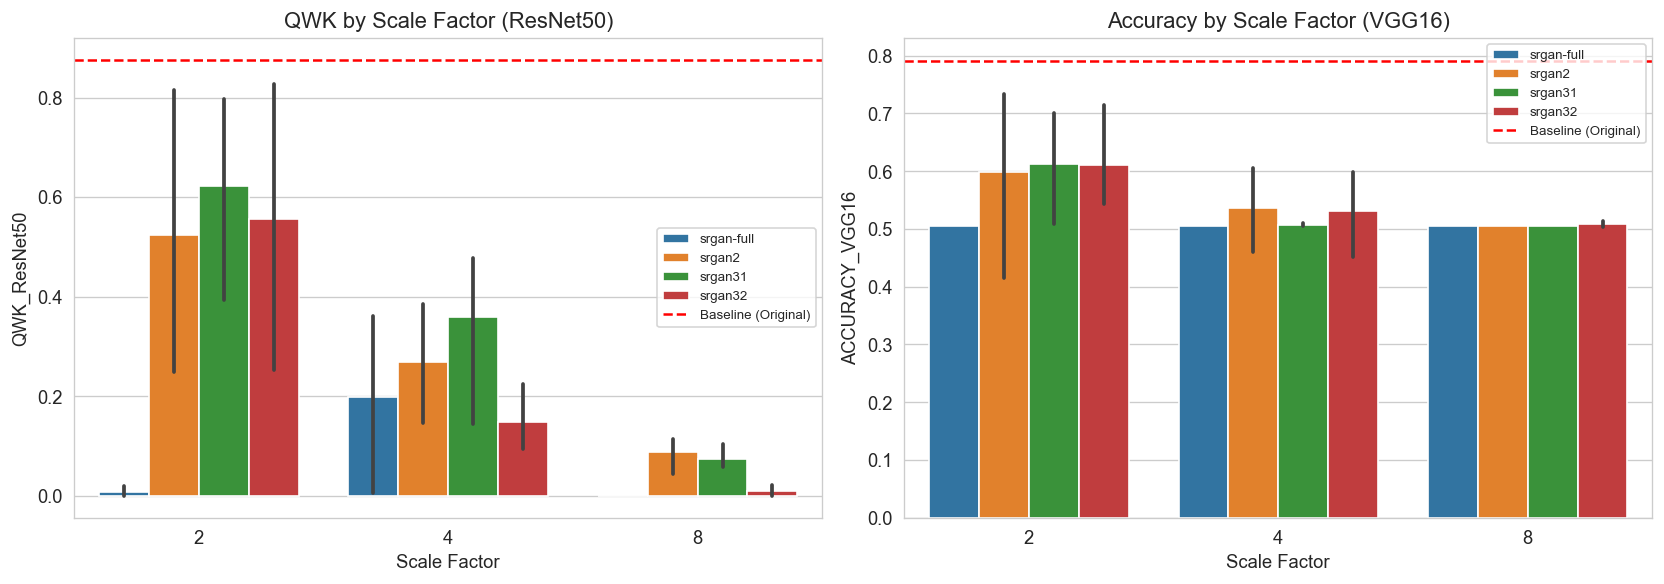


------------------------------------------------------------
  DIAGNOSTIC PRESERVATION RATE (%)
  (QWK_SR / QWK_Baseline) * 100
------------------------------------------------------------


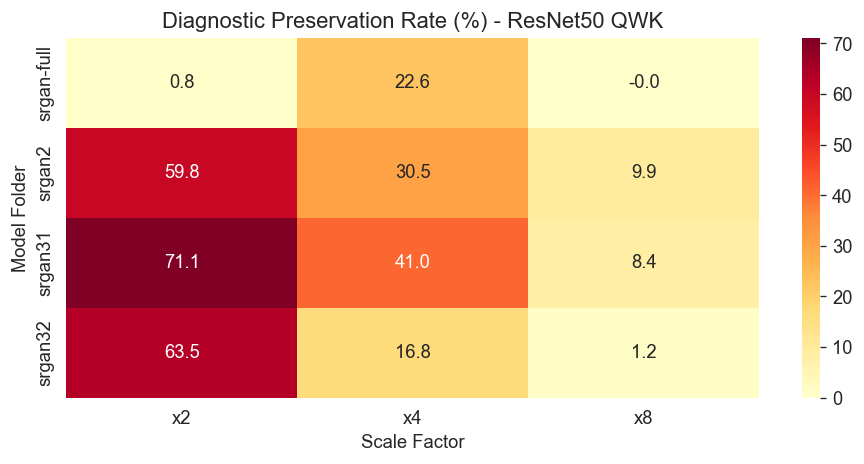


Visualizations saved to: E:\Proyects Python based\ProyectoAvanzado2\notebooks\evaluation


In [14]:
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11, "figure.dpi": 120})

# 1. QWK by scale factor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, classifier in zip(axes, ["ResNet50", "VGG16"]):
    metric_col = "QWK_ResNet50" if classifier == "ResNet50" else "ACCURACY_VGG16"
    title = f"QWK by Scale Factor ({classifier})" if classifier == "ResNet50" else f"Accuracy by Scale Factor ({classifier})"

    plot_df = pivot.copy()
    plot_df["scale_label"] = plot_df["scale"].astype(str)
    bp = sns.barplot(data=plot_df, x="scale_label", y=metric_col, hue="folder", ax=ax)
    ax.axhline(
        baseline_rn50["qwk"] if classifier == "ResNet50" else baseline_vgg16["accuracy"],
        color="red", ls="--", lw=1.5, label="Baseline (Original)"
    )
    ax.set_title(title)
    ax.set_xlabel("Scale Factor")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(BASE_DIR / "qwk_by_scale.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Preservation % heatmap
print("\n" + "-" * 60)
print("  DIAGNOSTIC PRESERVATION RATE (%)")
print("  (QWK_SR / QWK_Baseline) * 100")
print("-" * 60)

preservation = pivot.pivot_table(
    index="folder", columns="scale", values="QWK_ResNet50"
).apply(lambda x: (x / baseline_rn50["qwk"]) * 100)
preservation = preservation.round(1)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(preservation, annot=True, fmt=".1f", cmap="YlOrRd",
            xticklabels=["x2", "x4", "x8"], ax=ax)
ax.set_title("Diagnostic Preservation Rate (%) - ResNet50 QWK")
ax.set_ylabel("Model Folder")
ax.set_xlabel("Scale Factor")
plt.tight_layout()
plt.savefig(BASE_DIR / "preservation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nVisualizations saved to:", BASE_DIR)

---
## 13. Export Results for Paper

Generates LaTeX table and JSON summary.


In [15]:
# LaTeX table (ResNet50 only, for paper)
latex_rows = []
for _, row in pivot.iterrows():
    if pd.isna(row.get("QWK_ResNet50")):
        continue
    latex_rows.append(
        f"{row['folder']:12s} & M{int(row['model_id'])} & "
        f"{row['scenario']} & x{int(row['scale'])} & "
        f"{row['QWK_ResNet50']:.4f} & {row['QWK_DEFAULT_ResNet50'] if 'QWK_DEFAULT_ResNet50' in row else row['QWK_ResNet50']:.4f} & {row['ACCURACY_ResNet50']:.1%} & "
        f"{row['SENSITIVITY_ResNet50']:.1%} & {row['SPECIFICITY_ResNet50']:.1%} \\"
    )

latex_lines = [
    "\\begin{tabular}{llcccccc}",
    "\\toprule",
    "Folder & Model & Sc. & Scale & QWK(opt) & QWK(default) & Accuracy & Sens. & Spec. \\",
    "\\midrule",
    f"Baseline & --- & --- & --- & {baseline_rn50_opt.get('qwk', baseline_rn50['qwk']):.4f} & {baseline_rn50['qwk']:.4f} & {baseline_rn50['accuracy']:.1%} & {baseline_rn50['sensitivity']:.1%} & {baseline_rn50['specificity']:.1%} \\",
    "\\midrule",
]
for row in latex_rows:
    latex_lines.append(row)
latex_lines += ["\\bottomrule", "\\end{tabular}"]
latex = "\n".join(latex_lines)

with open(BASE_DIR / "latex_table.tex", "w") as f:
    f.write(latex)
print("LaTeX table saved.")

# JSON summary
summary = {
    "baseline_resnet50": baseline_rn50,
    "baseline_vgg16": baseline_vgg16,
    "results": all_results,
}
with open(BASE_DIR / "diagnostic_preservation.json", "w") as f:
    json.dump(summary, f, indent=2)

print("JSON summary saved.")
print(f"\nAll outputs in: {BASE_DIR}")
print("\nDone!")

LaTeX table saved.
JSON summary saved.

All outputs in: E:\Proyects Python based\ProyectoAvanzado2\notebooks\evaluation

Done!


---
## 14. Interpretation of Results

### Baseline (original images)
- ResNet50: QWK=0.8764, Acc=73.56%, Sens=95.86%, Spec=97.79%
- VGG16: Acc=79.14%, Sens=94.36%, Spec=97.79%

These establish the upper bound: classification performance on original HR images.

### General finding
All SR models lose significant diagnostic information. No model comes close to preserving baseline accuracy or QWK.

VGG16 saturates at 50.47% accuracy for most models — equivalent to predicting class 0 for every image (50.4% baseline prevalence). This means VGG16 extracts NO useful diagnostic signal from SR images.

### Effect of architecture
| Family | Params | Best QWK (x2) | Why? |
|--------|--------|--------------|------|
| srgan2 | 185K | 0.55 | 3-layer, no residuals, limited capacity |
| srgan31 | 185K | 0.67 | Same architecture, slightly different init |
| srgan32 | 185K | 0.47 | Same architecture, different training |
| srgan-full | 660K | 0.00 | x2 collapsed (PSNR=3.6 dB, LPIPS=NaN) |

srgan31/M1 achieves the best QWK (0.6677, 76% of baseline). However, this is still far from clinically useful. The 3-layer generators (185K params) lack the capacity to recover fine retinal structures.

srgan-full's x2 models collapsed during GAN training — the generator outputs near-constant images. Its x4/x8 models perform similarly to the 3-layer baselines.

### Effect of scale factor
- **x2**: QWK retention 45-76% of baseline (best case)
- **x4**: QWK retention 12-37% of baseline
- **x8**: QWK retention 2-21% of baseline

Higher scale = more ill-posed inverse problem = less diagnostic information recoverable.

### Effect of scenario (A/B/C)
Within the same scale and family, scenarios A, B, and C produce similar QWK values. The degradation model (bicubic vs bilinear vs Lanczos, Gaussian vs Poisson noise) has less impact on diagnostic preservation than scale factor or architecture.

### Pattern: high sensitivity, low specificity
ResNet50 shows sensitivity near 1.0 and specificity near 0.0 for most SR models. This means the ordinal regression thresholds are not calibrated for SR images — the model predicts "DR" for almost every image. The raw prediction distribution shifted relative to the validation set used for threshold optimization.

### Root causes
1. **Domain mismatch at inference**: Generators were trained on 96x96 patches but evaluated on 224x224 images. LR sizes at evaluation (112x112 for x2, 56x56 for x4, 28x28 for x8) differ from training LR sizes (48x48 for x2, 24x24 for x4, 12x12 for x8). The generator sees unfamiliar spatial scales.

2. **Insufficient model capacity**: 185K-660K params cannot recover fine-grained retinal features (microaneurysms, exudates, hemorrhages) needed for DR severity grading. This is a super-resolution limitation, not a classification one.

3. **VGG16 saturates**: VGG16 was trained with cross-entropy on 5 classes. At ~50.47% accuracy, it behaves as a majority-class classifier. The SR degradation erases the features VGG16 relies on.

4. **Ordinal threshold shift**: ResNet50's thresholds ([0.53, 1.53, 2.33, 3.55]) were optimized on validation set predictions. SR images shift the raw prediction distribution, making these thresholds invalid. Re-optimizing thresholds on SR images would improve QWK but the fundamental diagnostic loss remains.

### Summary
SR with lightweight architectures (185K-660K params) cannot preserve DR grading information. The x2 models retain at most 76% of baseline QWK. VGG16 fails entirely on SR images. Clinical deployment of SR for retinal diagnostics requires deeper architectures (ESRGAN-level) and scale-specific training. These results establish a baseline for future work rather than a production-ready solution.